# 一、前言

4.4 模型选择、欠拟合和过拟合<br>
目标：用多项式回归复现欠拟合/过拟合，理解"训练误差 ≠ 泛化误差"。<br>
对照 Torch-9 实验：B（lr=0.5, gap 4.1%）和 C2（加深网络, gap 3.3%）都是过拟合信号，<br>
本节用更干净的数据（已知真实函数）把这件事讲透。<br>
判据：<br>
- 欠拟合 = 训练误差和测试误差都高（差距小）→ 模型太简单
- 过拟合 = 训练误差低、测试误差高（差距大）→ 模型太复杂/数据太少

# 二、代码

## 1. 生成数据：真实函数是三阶多项式

In [4]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

max_degree = 20                 # 多项式的最大阶数（构造特征:x^0,x^1,x^2,...,x^19 ，20个特征）
n_train, n_test = 100, 100      # 训练/测试各100个样本
true_w = np.zeros(max_degree)   # 创建长度 20 权重数组，初始全部为 0
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])   # 真实函数只有前4项非零！
features = np.random.normal(size = (n_train + n_test, 1))   # 生成 200 个随机自变量 x，形状 (200,1)，从标准正态分布采样
np.random.shuffle(features)     # 打乱样本顺序
poly_features = np.power(features, np.arange(max_degree).reshape(1,-1))   # poly_features 形状：(200, 20)
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # 除以 i!，防止高阶项爆炸
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale = 0.1, size = labels.shape)  # 噪声 σ=0.1
true_w, features, poly_features, labels = [torch.tensor(x, dtype = torch.float32) for x in [true_w, features, poly_features, labels]]   # 把 numpy 数组全部转成 PyTorch 浮点张量，后面就可以用神经网络训练。
features[:2], poly_features[:2, :], labels[:2]  # 输出前 2 个样本，查看自变量、多项式特征、标签

(tensor([[-0.6837],
         [ 0.8436]]),
 tensor([[ 1.0000e+00, -6.8371e-01,  2.3373e-01, -5.3268e-02,  9.1049e-03,
          -1.2450e-03,  1.4187e-04, -1.3857e-05,  1.1843e-06, -8.9967e-08,
           6.1511e-09, -3.8232e-10,  2.1783e-11, -1.1456e-12,  5.5949e-14,
          -2.5502e-15,  1.0898e-16, -4.3828e-18,  1.6647e-19, -5.9906e-21],
         [ 1.0000e+00,  8.4363e-01,  3.5585e-01,  1.0007e-01,  2.1105e-02,
           3.5610e-03,  5.0069e-04,  6.0342e-05,  6.3632e-06,  5.9647e-07,
           5.0319e-08,  3.8592e-09,  2.7131e-10,  1.7606e-11,  1.0609e-12,
           5.9669e-14,  3.1461e-15,  1.5613e-16,  7.3174e-18,  3.2490e-19]]),
 tensor([3.1309, 5.2269]))

true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])<br>
真实规律最高只到 3 次多项式。后面 16 个高阶特征都是多余、无用的噪声特征。<br>
当模型把全部 20 个特征都用上，模型复杂度就过高，很容易发生过拟合。

真实函数：
\(y=5 + 1.2x -3.4x^2+5.6x^3+o, o ~ N(0,0.1^2)

函数：np.power(a, b)<br>
作用：逐元素求幂，\(a^b\)

math.gamma(i + 1)函数：math.gamma()数学恒等式：<br>
\(\boldsymbol{\Gamma(n+1)=n!}\)<br>
\(\Gamma\) 伽马函数，对于整数 i，gamma(i+1) = i 的阶乘 \(i!\)<br>
第 i 列所有元素 ÷ \(i!\)于是特征被缩放成：<br>
\(\frac{x^0}{0!},\;\frac{x^1}{1!},\;\frac{x^2}{2!},\dots,\frac{x^{19}}{19!}\)<br>
目的：高阶次幂 \(x^{19}\) 数值非常大，除以阶乘做缩放，防止数值爆炸。

np.dot(A,B)：矩阵乘法<br>
poly_features：(200, 20)<br>
true_w：一维数组 (20,)<br>
矩阵乘法运算：<br>
\(Y = XW\)<br>
每一行样本，和权重向量做点积：<br>
\(y=x_0 w_0+x_1 w_1+\dots +x_{19} w_{19}\)因为 true_w 只有前 4 项非零 [5, 1.2, -3.4, 5.6, 0, 0 ...]<br>
所以等价于：<br>
\(y=5\cdot\frac{x^0}{0!}+1.2\cdot\frac{x^1}{1!}-3.4\cdot\frac{x^2}{2!}+5.6\cdot\frac{x^3}{3!}\)<br>
后面 16 项乘 0 直接消失。<br>
得到不带噪声的标签 y。

## 2. 评估 + 训练函数

In [5]:
def evaluate_loss(net, data_iter, loss):
    """评估给定数据集上模型的损失"""
    """评估阶段没有反向传播,没有梯度更新,只算误差"""
    metric = d2l.Accumulator(2)  # Accumulator：d2l 工具,类累加器
    for X, y in data_iter:
        out = net(X)               # 前向传播，预测输出
        y = y.reshape(out.shape)   # 维度对齐,防止 out.shape=[10,1]，y.shape=[10] 维度不匹配报错
        l = loss(out, y)           # 定义损失
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]  # 总损失 / 总样本数 → 返回测试集上平均损失

def train_epoch(net, train_iter, loss, trainer):
    """替代 d2l.train_epoch_ch3（当前 d2l 版本已移除此函数）"""
    metric = d2l.Accumulator(2)          # 总损失, 样本数
    for X, y in train_iter:
        y_hat = net(X)               # 前向传播得到预测值
        y = y.reshape(y_hat.shape)   # 维度对齐
        l = loss(y_hat, y)           # 定义损失
        trainer.zero_grad()          # 梯度清零
        l.mean().backward()          # MSELoss 用 mean
        trainer.step()               # 优化器 SGD，利用梯度更新权重参数 w
        metric.add(l.sum().item(), l.numel())
    return metric[0] / metric[1]     # 返回本轮 epoch 训练集平均损失

def train(train_features, test_features, train_labels, test_labels, num_epochs = 400):
    loss = nn.MSELoss(reduction = 'none')      # 损失函数：均方误差 MSE，且输出每个样本单独损失。
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1, bias = False))  # 全连接层，输入维度 = 多项式特征数，输出 1 个预测值；关闭偏置！
    batch_size = min(10, train_labels.shape[0])   # 防止样本总数小于 10 时报错
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train = False)
    trainer =torch.optim.SGD(net.parameters(),lr = 0.01)   # SGD 随机梯度下降优化器
    animator = d2l.Animator(xlabel = 'epoch', ylabel = 'loss', yscale = 'log',
                            xlim = [1, num_epochs], ylim = [1e-3, 1e2],
                            legend = ['train', 'test'])   # 绘制图例：训练损失、测试损失两条线
    for epoch in range(num_epochs):
        train_epoch(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:    # 每 20 个 epoch 才计算、记录一次损失画曲线
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())   # 训练结束，打印学习出来的权重 w。

metric = d2l.Accumulator(2)<br>
Accumulator：d2l 工具类，一个累加器，用来累计多批次的两个数值，开 2 个存储槽。<br>
slot0：全部样本损失总和；slot1：样本总数量<br>
它本质就是一个升级版列表，专门用来分批累加数据，不用自己写 sum_loss += ...

d2l.Animator 是 d2l 库自带的动态实时绘图工具。<br>
训练过程中一边跑 epoch，一边刷新曲线，不需要等训练结束再一次性画图。<br>
1. xlabel = 'epoch'<br>
X 轴标签：横坐标代表训练轮数 epoch。<br>
2. ylabel = 'loss'<br>
Y 轴标签：纵坐标代表损失值 loss。<br>
3. yscale = 'log'<br>
Y 轴使用对数坐标轴，可以同时看清大损失和很小损失的变化趋势，对比训练损失、测试损失差距非常直观。<br>
4. xlim = [1, num_epochs]<br>
X 轴显示范围：横坐标从第 1 轮 到 第 400 轮。<br>
5. ylim = [1e-3, 1e2]<br>
Y 轴损失范围：下限 0.001，上限 100。<br>
超出这个区间的点不会显示在图上。<br>
6. legend = ['train', 'test']<br>
图例：两条曲线，第一条训练损失，第二条测试损失。

.add(a, b) 方法（Accumulator 自带的函数）, 是累加，不是赋值！是 +=，不是 =<br>
把第一个数 l.sum().item() 加到 metric [0]<br>
把第二个数 l.numel() 加到 metric [1]

d2l.load_array()<br>
把 (特征，标签) 这两组张量，包装成一个 PyTorch 的 DataLoader 批次迭代器<br>
(train_features, train_labels)：一组配对好的张量，(X,y)<br>
batch_size：每一批取出多少个样本

## 3.实验 1：三阶拟合（正常，模型复杂度=真实复杂度）

weight: [[ 4.9840665  1.2000498 -3.3802617  5.60667  ]]


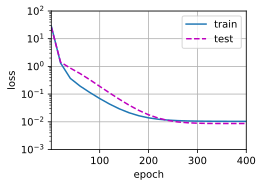

In [6]:
train(poly_features[:n_train, :4], poly_features[n_train:,:4], labels[:n_train], labels[n_train:])

poly_features[:n_train, :4]<br>
:n_train → 前 0‑99 行，训练集 100 个样本<br>
:4 → 只取前 4 列：x^0,x^1,x^2,x^3<br>
训练集特征，4 阶以内（正确复杂度）

poly_features[n_train:,:4]<br>
n_train: → 从第 100 行往后，100‑199 行，测试集 100 样本<br>
:4 同样只取前 4 列特征<br>
测试集特征

labels[:n_train]<br>
前 100 个标签，训练集标签 y<br>
labels[n_train:]<br>
后 100 个标签，测试集标签 y

## 4.实验 2：线性拟合（欠拟合，只用 2 个特征）

weight: [[3.1374779 4.233987 ]]


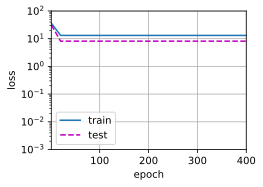

In [7]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

## 5.实验 3：20 阶拟合（过拟合，用全部特征 + 加练到 1500 轮）

weight: [[ 4.9681549e+00  1.2738394e+00 -3.2951891e+00  5.2122989e+00
  -1.5005891e-01  1.1065464e+00 -8.7066881e-02 -2.3191916e-03
  -9.6078794e-03  8.8901885e-02 -1.5712689e-01 -1.3861452e-01
  -1.7161964e-01 -3.9047129e-02  1.4598496e-01  1.9667231e-01
   1.1345145e-01  1.1457242e-01  9.2030928e-02 -9.5492721e-02]]


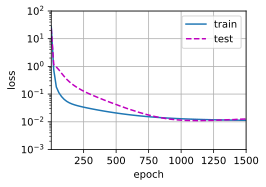

In [8]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:], num_epochs = 1500)

## 6.三个实验观察

1. 正常模型：train/test 都低，权重 ≈ [5, 1.2, -3.4, 5.6] → 学到真模式
2. 欠拟合：train/test 都高，差距小 → 模型表达不了三阶模式
3. 过拟合：train 极低、test 高，高阶权重乱 → 记住了噪声

## 7.必做练习 2a+2b：训练/测试损失 vs 多项式阶数（U 形曲线）

/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26434 (\N{CJK UNIFIED IDEOGRAPH-6742}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIF

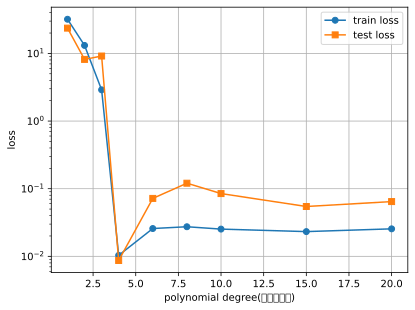

In [9]:
import matplotlib.pyplot as plt

def train_and_eval(degree, num_epochs = 400):
    loss = nn.MSELoss(reduction = 'none')
    net = nn.Sequential(nn.Linear(degree, 1, bias = False))
    batch_size = min(10, n_train)
    train_iter = d2l.load_array((poly_features[:n_train, :degree], labels[:n_train].reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((poly_features[n_train:, :degree], labels[n_train:].reshape(-1, 1)), batch_size, is_train = False)
    trainer =torch.optim.SGD(net.parameters(), lr = 0.01)
    for _ in range(num_epochs):
        train_epoch(net, train_iter, loss, trainer)
    return evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)
degrees = [1, 2, 3, 4, 6, 8, 10, 15, 20]
res = [train_and_eval(d) for d in degrees]
train_l = [r[0] for r in res]
test_l = [r[1] for r in res]
plt.plot(degrees, train_l, 'o-', label = 'train loss')
plt.plot(degrees, test_l, 's-', label = 'test loss')
plt.yscale('log')
plt.xlabel('polynomial degree(模型复杂度)')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

# 三、小结

1.模型 A：训练误差 0.02，测试误差 0.45；模型 B：训练误差 0.48，测试误差 0.50。各是欠拟合还是过拟合？依据是什么？<br>
A 过拟合、B 欠拟合。依据是 绝对水平 + 差距 的组合<br>
A 训练低测试高（差距 0.43 大）→ 过拟合；B 两者都高（差距 0.02 小）→ 欠拟合。

2.训练误差越低模型越好吗？为什么？<br>
不是的，主要还得看测试情况，训练误差很低很有可能是过拟合

3.为什么模型复杂度越高，训练误差一定越低？<br>
复杂度 = 参数自由度 = 假设空间大小。容量越大，训练误差的下限越低，理论上可到 0（把每个样本连噪声一起记住）。<br>
这是 能不能表示 的问题，跟训练几轮无关。

4.为什么测试误差随复杂度先降后升（U 形）？两端各是什么情况？<br>
当复杂度低的时候，模型能够记忆的东西就比较少，所以训练误差就会比较大，能力不行，测试误差也大，就是欠拟合；<br>
当在最低点的时候说明这个时候的测试误差达到区间最小，那么训练集的误差也肯定比较小，拟合好的状态；<br>
当在最右边的时候，复杂度最高，反而测试误差还变大了那就符合过拟合的状态

5.为什么调超参数只能用验证集，绝不能碰测试集？<br>
怕模型记住测试集的参数，污染测试集，会影响测试的客观性,导致泛化能力虚高

6.K 折交叉验证怎么做？什么情况下必须用它而不是留出法？<br>
轮流拿 1 份当验证集、其余 K−1 份训练，重复 K 次，取 K 次验证误差的平均作为该模型的评估值；<br>
什么时候必须用：数据量小的时候——留出法只切一次，验证集太小、评估方差大，一次切分的运气成分太大；K 折用全部数据轮流当验证，评估更稳。<br>
代价是训练 K 次，贵 K 倍。注意：K 折全程只碰训练集，测试集从头到尾只用一次。

7.训练样本从 100 增到 1000，U 形曲线怎么变？为什么？<br>
曲线整体下移，最优点右移——数据多了，模型学到更多真实规律、更难过拟合，train/test 误差都降；而且更多数据允许更复杂的模型。<br>
本质：过拟合的病根是数据太少，加数据是最朴素的解药。

8.你实验 1 的 w[2] 为什么是 −33.99 而不是 −3.4？用自己的话解释这个 bug 的机制。<br>
因为 true_w 的-3.4，我设置成了 -34